In [1]:
from datetime import date, timedelta
from math import pi
from typing import Any

import openmeteo_requests
import polars as pl
import pandas as pd
import seaborn as sns
import requests_cache
import holidays
import plotly.express as px
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
from retry_requests import retry

# Data Prep

### Academic Calender

**Helpers**

In [10]:
def _period_label(
    periods: list[dict[str, Any]],
    label_col: str,
    start_col: str,
    end_col: str,
) -> pl.Expr:
    expr = pl.lit(None, dtype=pl.Utf8)
    for period in periods:
        expr = (
            pl.when(pl.col('day').is_between(period[start_col], period[end_col], closed='both'))
            .then(pl.lit(period[label_col]))
            .otherwise(expr)
        )
    return expr


def _in_period(periods: list[dict[str, Any]], start_col: str, end_col: str) -> pl.Expr:
    expr = pl.lit(False)
    for period in periods:
        expr = expr | pl.col('day').is_between(period[start_col], period[end_col], closed='both')
    return expr


def _in_relative_lecture_start_window(
    semester_terms: list[dict[str, Any]],
    start_offset_days: int,
    end_offset_days: int,
) -> pl.Expr:
    expr = pl.lit(False)
    for period in semester_terms:
        window_start = period['lecture_start'] + timedelta(days=start_offset_days)
        window_end = period['lecture_start'] + timedelta(days=end_offset_days)
        expr = expr | pl.col('day').is_between(window_start, window_end, closed='both')
    return expr


def _date_range_rows(
    ranges: dict[str, tuple[date, date]],
    description_col: str,
) -> list[dict[str, Any]]:
    return [
        {
            'day': start + timedelta(days=offset),
            description_col: description,
        }
        for description, (start, end) in ranges.items()
        for offset in range((end - start).days + 1)
    ]


def _date_range_frame(
    ranges: dict[str, tuple[date, date]],
    description_col: str,
) -> pl.DataFrame:
    return pl.DataFrame(
        _date_range_rows(ranges, description_col),
        schema={'day': pl.Date, description_col: pl.Utf8},
    )

**Variables**

In [11]:
semester_terms = [
    {
        'semester': 'winter_2024_2025',
        'semester_season': 'winter',
        'semester_start': date(2024, 10, 1),
        'semester_end': date(2025, 3, 31),
        'lecture_start': date(2024, 10, 21),
        'lecture_end': date(2025, 2, 15),
    },
    {
        'semester': 'summer_2025',
        'semester_season': 'summer',
        'semester_start': date(2025, 4, 1),
        'semester_end': date(2025, 9, 30),
        'lecture_start': date(2025, 4, 14),
        'lecture_end': date(2025, 7, 19),
    },
    {
        'semester': 'winter_2025_2026',
        'semester_season': 'winter',
        'semester_start': date(2025, 10, 1),
        'semester_end': date(2026, 3, 31),
        'lecture_start': date(2025, 10, 13),
        'lecture_end': date(2026, 2, 14),
    },
]

university_holidays = {
    'winter_2024_2025_christmas_break': (
        date(2024, 12, 23),
        date(2025, 1, 5),
    ),
    'winter_2025_2026_christmas_break': (
        date(2025, 12, 22),
        date(2026, 1, 7),
    ),
}

**Calendar Builder**

In [21]:
public_holidays = holidays.country_holidays(
    'DE',
    subdiv='RP',
    years=[2025],
)
public_holiday_df = pl.DataFrame(
    [
        {'day': holiday_day, 'public_holiday_name': holiday_name}
        for holiday_day, holiday_name in sorted(public_holidays.items())
    ],
    schema={'day': pl.Date, 'public_holiday_name': pl.Utf8},
)
university_holiday_df = _date_range_frame(
    university_holidays,
    'university_holiday_name',
)

days_in_year = (date(2026, 1, 1) - date(2025, 1, 1)).days

calendar = (
    pl.DataFrame(
        {
            'day': pl.date_range(
                date(2025, 1, 1),
                date(2025, 12, 31),
                interval='1d',
                eager=True,
            )
        }
    )
    .with_columns(
        weekday=pl.col('day').dt.strftime('%A'),
        day_of_week=pl.col('day').dt.weekday(),
        day_of_month=pl.col('day').dt.day(),
        day_of_year=pl.col('day').dt.ordinal_day(),
    )
    .with_columns(
        week_sin=((pl.col('day_of_week').cast(pl.Float64) - 1) * 2 * pi / 7).sin(),
        week_cos=((pl.col('day_of_week').cast(pl.Float64) - 1) * 2 * pi / 7).cos(),
        month_sin=((pl.col('day_of_year').cast(pl.Float64) - 1) * 2 * pi * 12 / days_in_year).sin(),
        month_cos=((pl.col('day_of_year').cast(pl.Float64) - 1) * 2 * pi * 12 / days_in_year).cos(),
        year_sin=((pl.col('day_of_year').cast(pl.Float64) - 1) * 2 * pi / days_in_year).sin(),
        year_cos=((pl.col('day_of_year').cast(pl.Float64) - 1) * 2 * pi / days_in_year).cos(),
        is_weekend=pl.col('day_of_week').is_in([6, 7]),
        semester=_period_label(semester_terms, 'semester', 'semester_start', 'semester_end'),
        is_semester_day=_in_period(semester_terms, 'semester_start', 'semester_end'),
        is_lecture_day=_in_period(semester_terms, 'lecture_start', 'lecture_end'),
        is_orientation_week=_in_relative_lecture_start_window(semester_terms, -7, -1),
        is_first_lecture_week=_in_relative_lecture_start_window(semester_terms, 0, 6),
    )
    .join(public_holiday_df, on='day', how='left')
    .join(university_holiday_df, on='day', how='left')
    .with_columns(
        is_public_holiday=pl.col('public_holiday_name').is_not_null(),
        is_university_holiday=pl.col('university_holiday_name').is_not_null(),
    )
    .with_columns(
        is_university_closure=pl.col('is_public_holiday') | pl.col('is_university_holiday'),
    )
    .with_columns(
        academic_bucket=pl.when(pl.col('is_university_closure'))
        .then(pl.lit('university_closure'))
        .when(pl.col('is_lecture_day'))
        .then(pl.lit('lecture'))
        .when(pl.col('is_semester_day'))
        .then(pl.lit('lecture_free'))
        .otherwise(pl.lit('semester_break')),
        is_cafeteria_relevant_day=~pl.col('is_weekend'),
        is_regular_service_day=(~pl.col('is_weekend')) & (~pl.col('is_university_closure')),
    )
)

cafeteria_calendar = calendar.rename({'day': 'date'})
cafeteria_calendar

date,weekday,day_of_week,day_of_month,day_of_year,week_sin,week_cos,month_sin,month_cos,year_sin,year_cos,is_weekend,semester,is_semester_day,is_lecture_day,is_orientation_week,is_first_lecture_week,public_holiday_name,university_holiday_name,is_public_holiday,is_university_holiday,is_university_closure,academic_bucket,is_cafeteria_relevant_day,is_regular_service_day
date,str,i8,i8,i16,f64,f64,f64,f64,f64,f64,bool,str,bool,bool,bool,bool,str,str,bool,bool,bool,str,bool,bool
2025-01-01,"""Wednesday""",3,1,1,0.974928,-0.222521,0.0,1.0,0.0,1.0,false,"""winter_2024_2025""",true,true,false,false,"""Neujahr""","""winter_2024_2025_christmas_bre…",true,true,true,"""university_closure""",true,false
2025-01-02,"""Thursday""",4,2,2,0.433884,-0.900969,0.205104,0.97874,0.017213,0.999852,false,"""winter_2024_2025""",true,true,false,false,null,"""winter_2024_2025_christmas_bre…",false,true,true,"""university_closure""",true,false
2025-01-03,"""Friday""",5,3,3,-0.433884,-0.900969,0.401488,0.915864,0.034422,0.999407,false,"""winter_2024_2025""",true,true,false,false,null,"""winter_2024_2025_christmas_bre…",false,true,true,"""university_closure""",true,false
2025-01-04,"""Saturday""",6,4,4,-0.974928,-0.222521,0.5808,0.814046,0.05162,0.998667,true,"""winter_2024_2025""",true,true,false,false,null,"""winter_2024_2025_christmas_bre…",false,true,true,"""university_closure""",false,false
2025-01-05,"""Sunday""",7,5,5,-0.781831,0.62349,0.735417,0.677615,0.068802,0.99763,true,"""winter_2024_2025""",true,true,false,false,null,"""winter_2024_2025_christmas_bre…",false,true,true,"""university_closure""",false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-12-27,"""Saturday""",6,27,361,-0.974928,-0.222521,-0.858764,0.512371,-0.085965,0.996298,true,"""winter_2025_2026""",true,true,false,false,null,"""winter_2025_2026_christmas_bre…",false,true,true,"""university_closure""",false,false
2025-12-28,"""Sunday""",7,28,362,-0.781831,0.62349,-0.735417,0.677615,-0.068802,0.99763,true,"""winter_2025_2026""",true,true,false,false,null,"""winter_2025_2026_christmas_bre…",false,true,true,"""university_closure""",false,false
2025-12-29,"""Monday""",1,29,363,0.0,1.0,-0.5808,0.814046,-0.05162,0.998667,false,"""winter_2025_2026""",true,true,false,false,null,"""winter_2025_2026_christmas_bre…",false,true,true,"""university_closure""",true,false


### Sales Data

In [22]:
sales_raw = pl.read_csv('../../data/raw/Produktions-Ausgabemengen Mensa Tarforst_Mensa Oliva.csv',
                        skip_rows=1,
                        separator=';',
                        try_parse_dates=True,
                        decimal_comma=True,
                        columns=[1,2,3,4],
                        )

# drop oliva entries
sales_raw = sales_raw.filter(~pl.col('Prod.Art').str.contains('Oliva'))

# take the maximum of duplicate entries. technically this abstracts a bit from the data since there are fields where sweet joker is correctly differentiated but these are not many. We assume that the max is a good enough proxy for total sold dishes of that category.
sales_de_duped = sales_raw.group_by(['Prod.Datum', 'Prod.Art', 'Rezeptur']).agg(pl.col('Ist-Menge').max())
sales_processed = sales_de_duped.rename({
    'Prod.Datum': 'date',
    'Prod.Art': 'meal_category',
    'Rezeptur': 'meal_name',
    'Ist-Menge': 'sales',
})
sales_processed.sort(pl.col('date')).write_csv('../../data/processed/sales_2025_processed_from_csv.csv')

### Weather Data

In [23]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = 'https://archive-api.open-meteo.com/v1/archive'
params = {
	'latitude': 49.7557,
	'longitude': 6.6394,
	'start_date': '2025-01-01',
	'end_date': '2026-01-01',
	'daily': ['sunshine_duration', 'precipitation_hours', 'apparent_temperature_mean', 'precipitation_sum'],
	'timezone': 'Europe/Berlin',
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f'Coordinates: {response.Latitude()}°N {response.Longitude()}°E')
print(f'Elevation: {response.Elevation()} m asl')
print(f'Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}')
print(f'Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s')

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_sunshine_duration = daily.Variables(0).ValuesAsNumpy()
daily_precipitation_hours = daily.Variables(1).ValuesAsNumpy()
daily_apparent_temperature_mean = daily.Variables(2).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(3).ValuesAsNumpy()

daily_data = {'date': pd.date_range(
    start=pd.to_datetime(daily.Time(), unit='s', utc=True),
    end=pd.to_datetime(daily.TimeEnd(), unit='s', utc=True),
    freq=pd.Timedelta(seconds=daily.Interval()),
    inclusive='left'
).tz_convert(response.Timezone().decode()), 'sunshine_duration': daily_sunshine_duration,
              'precipitation_hours': daily_precipitation_hours,
              'apparent_temperature_mean': daily_apparent_temperature_mean,
              'precipitation_sum': daily_precipitation_sum}

weather_df = pd.DataFrame(data = daily_data)
weather_df = pl.from_pandas(weather_df)
weather_df = weather_df.with_columns(
    (pl.col('sunshine_duration') / 3600).alias('sunshine_duration')
)
weather_df

Coordinates: 49.73637771606445°N 6.551126480102539°E
Elevation: 144.0 m asl
Timezone: b'Europe/Berlin'b'GMT+2'
Timezone difference to GMT+0: 7200s


date,sunshine_duration,precipitation_hours,apparent_temperature_mean,precipitation_sum
"datetime[ms, Europe/Berlin]",f32,f32,f32,f32
2024-12-31 23:00:00 CET,4.0,0.0,-2.342734,0.0
2025-01-01 23:00:00 CET,0.0,14.0,-0.293106,18.500002
2025-01-02 23:00:00 CET,2.85129,1.0,-3.807505,0.1
2025-01-03 23:00:00 CET,1.559662,0.0,-2.775087,0.0
2025-01-04 23:00:00 CET,0.0,20.0,1.469023,17.899998
…,…,…,…,…
2025-12-27 23:00:00 CET,7.462039,0.0,-2.705722,0.0
2025-12-28 23:00:00 CET,7.065905,0.0,-4.035481,0.0
2025-12-29 23:00:00 CET,6.035238,0.0,-2.340001,0.0


# Plotting

In [7]:
color_palette = {
    'rot': '#53A12E',
    'gelb': '#D02525',
    'grün': '#F3B700',
    'dunkelblau': '#22608F',
    'blau': '#3F92D2',
    'hellblau': '#85BAE2',
    'grau': '#9E9E9E',
}

### Feature DF merging

In [24]:
# join all dfs on the full cafeteria calendar
sales_daily = sales_processed.group_by(pl.col('date')).agg(pl.col('sales').sum())
weather_df = weather_df.with_columns(
    pl.col('date').dt.date().alias('date')
)

prepped_data = (cafeteria_calendar
                .join(weather_df, on='date', how='left')
                .join(sales_daily, on='date', how='left'))

# make categorical columns for sunny day with 6 or more hours of sunshine and rainy day with 6 or more hours of precipitation. additionally a rainy day is also classified by more than average precipitation_sum
# this is only for completeness purpose and can be ignored in the feature df. we used this to prove a point that a complex feature is not necessarily useful
threshold = 6

prepped_data = prepped_data.with_columns(
    pl.when(
        (pl.col('sunshine_duration') >= threshold) &
        (pl.col('precipitation_hours') < threshold)
    )
    .then(pl.lit('sunny'))
    .when(
        (pl.col('precipitation_hours') >= threshold) &
        (pl.col('sunshine_duration') < threshold) &
        (
            pl.col('precipitation_sum') >=
            pl.col('precipitation_sum').mean()
        )
    )
    .then(pl.lit('rainy'))
    .otherwise(pl.lit('normal'))
    .alias('weather_category')
)

In [25]:
# save final feature set to csv
# IMPORTANT: sales have intentional null values because these are days where null sales (not 0 sales) occured. this is by design and is valid for all university/cafeteria closure days
prepped_data.sort(pl.col('date')).write_csv('../../data/processed/final_feature_df.csv')
prepped_data.drop('sales').sort(pl.col('date')).write_csv('../../data/processed/final_feature_df_no_target.csv')
prepped_data.sort(pl.col('date'))

date,weekday,day_of_week,day_of_month,day_of_year,week_sin,week_cos,month_sin,month_cos,year_sin,year_cos,is_weekend,semester,is_semester_day,is_lecture_day,is_orientation_week,is_first_lecture_week,public_holiday_name,university_holiday_name,is_public_holiday,is_university_holiday,is_university_closure,academic_bucket,is_cafeteria_relevant_day,is_regular_service_day,sunshine_duration,precipitation_hours,apparent_temperature_mean,precipitation_sum,sales,weather_category
date,str,i8,i8,i16,f64,f64,f64,f64,f64,f64,bool,str,bool,bool,bool,bool,str,str,bool,bool,bool,str,bool,bool,f32,f32,f32,f32,i64,str
2025-01-01,"""Wednesday""",3,1,1,0.974928,-0.222521,0.0,1.0,0.0,1.0,false,"""winter_2024_2025""",true,true,false,false,"""Neujahr""","""winter_2024_2025_christmas_bre…",true,true,true,"""university_closure""",true,false,0.0,14.0,-0.293106,18.500002,null,"""rainy"""
2025-01-02,"""Thursday""",4,2,2,0.433884,-0.900969,0.205104,0.97874,0.017213,0.999852,false,"""winter_2024_2025""",true,true,false,false,null,"""winter_2024_2025_christmas_bre…",false,true,true,"""university_closure""",true,false,2.85129,1.0,-3.807505,0.1,null,"""normal"""
2025-01-03,"""Friday""",5,3,3,-0.433884,-0.900969,0.401488,0.915864,0.034422,0.999407,false,"""winter_2024_2025""",true,true,false,false,null,"""winter_2024_2025_christmas_bre…",false,true,true,"""university_closure""",true,false,1.559662,0.0,-2.775087,0.0,null,"""normal"""
2025-01-04,"""Saturday""",6,4,4,-0.974928,-0.222521,0.5808,0.814046,0.05162,0.998667,true,"""winter_2024_2025""",true,true,false,false,null,"""winter_2024_2025_christmas_bre…",false,true,true,"""university_closure""",false,false,0.0,20.0,1.469023,17.899998,null,"""rainy"""
2025-01-05,"""Sunday""",7,5,5,-0.781831,0.62349,0.735417,0.677615,0.068802,0.99763,true,"""winter_2024_2025""",true,true,false,false,null,"""winter_2024_2025_christmas_bre…",false,true,true,"""university_closure""",false,false,2.890229,8.0,4.693706,4.7,null,"""rainy"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-12-27,"""Saturday""",6,27,361,-0.974928,-0.222521,-0.858764,0.512371,-0.085965,0.996298,true,"""winter_2025_2026""",true,true,false,false,null,"""winter_2025_2026_christmas_bre…",false,true,true,"""university_closure""",false,false,7.462039,0.0,-2.705722,0.0,null,"""sunny"""
2025-12-28,"""Sunday""",7,28,362,-0.781831,0.62349,-0.735417,0.677615,-0.068802,0.99763,true,"""winter_2025_2026""",true,true,false,false,null,"""winter_2025_2026_christmas_bre…",false,true,true,"""university_closure""",false,false,7.065905,0.0,-4.035481,0.0,null,"""sunny"""
2025-12-29,"""Monday""",1,29,363,0.0,1.0,-0.5808,0.814046,-0.05162,0.998667,false,"""winter_2025_2026""",true,true,false,false,null,"""winter_2025_2026_christmas_bre…",false,true,true,"""university_closure""",true,false,6.035238,0.0,-2.340001,0.0,null,"""sunny"""


### Weather Category

<Axes: xlabel='weather_category', ylabel='sales'>

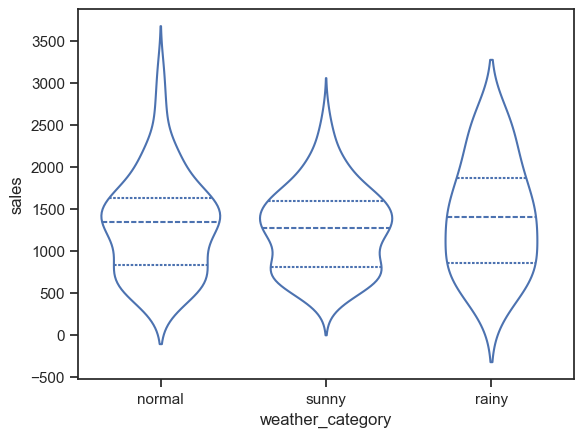

In [15]:
sns.set_theme('notebook', 'ticks')
sns.violinplot(data=prepped_data, x='weather_category', y='sales', fill=False, inner='quart', order=['normal', 'sunny', 'rainy'])

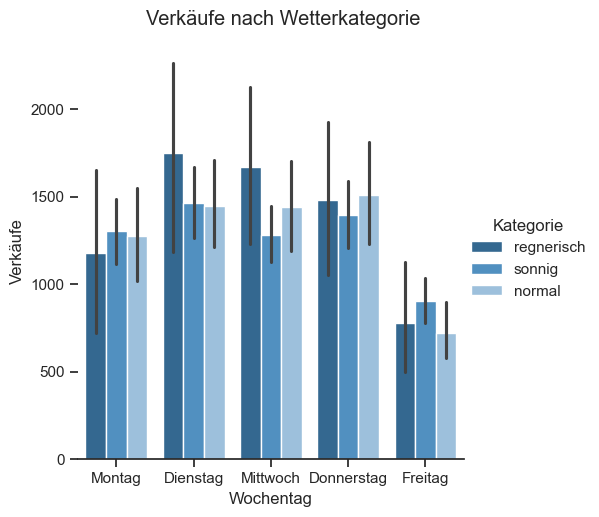

In [16]:
sns.set_theme('notebook', 'ticks')

weather_category_color_palette = {
    'regnerisch': '#256A9F',
    'sonnig': '#3F92D2',
    'normal': '#92C2E6',
}

mapping = {
    'rainy': 'regnerisch',
    'sunny': 'sonnig',
}

weather_category_plot_df = prepped_data.with_columns(
    pl.col('weather_category')
    .replace(mapping)
    .alias('Kategorie')
)

g = sns.catplot(data=weather_category_plot_df, x='weekday', y='sales', hue='Kategorie', hue_order=['regnerisch', 'sonnig', 'normal'], order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'], kind='bar', palette=weather_category_color_palette,)
g.set_axis_labels(x_var='Wochentag', y_var='Verkäufe')
g.set_xticklabels(['Montag', 'Dienstag', 'Mittwoch', 'Donnerstag', 'Freitag'])
g.figure.suptitle('Verkäufe nach Wetterkategorie', y=1.03)
g.despine(left=True)

g.savefig('../../plots/verkaeufe_nach_wetter.png')

### Temperature

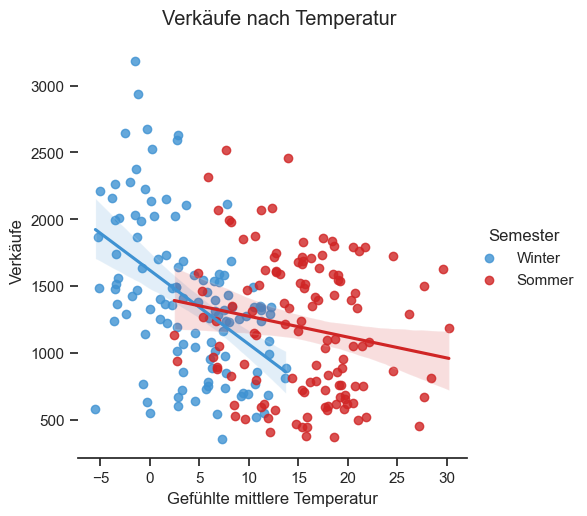

In [17]:
sns.set_theme('notebook', 'ticks')

apparent_temp_color_palette = {
    'Winter': '#3F92D2',
    'Sommer': '#D02525',
}

mapping = {
    'winter': 'Winter',
    'summer': 'Sommer',
}

apparent_temp_plot_df = prepped_data.with_columns(
    pl.col('semester_season')
    .replace(mapping)
    .alias('Semester')
)

g = sns.lmplot(data=apparent_temp_plot_df, x='apparent_temperature_mean', y='sales', hue='Semester', palette=apparent_temp_color_palette)
g.set_axis_labels(x_var='Gefühlte mittlere Temperatur', y_var='Verkäufe')
g.figure.suptitle('Verkäufe nach Temperatur', y=1.03)
g.despine(left=True)

g.savefig('../../plots/verkaeufe_nach_temperatur.png')

### Calendar Data

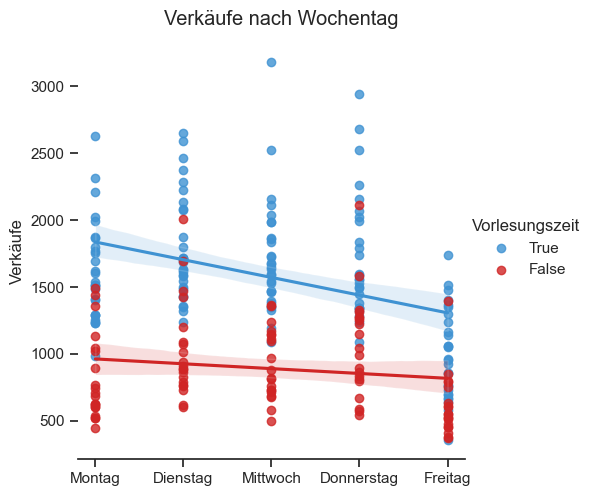

In [22]:
sns.set_theme('notebook', 'ticks')

weekday_color_palette = {
    'True': '#3F92D2',
    'False': '#D02525',
}

mapping = {
    'lecture': 'True',
    'lecture_free': 'False',
}

weekday_plot_df = (prepped_data
                   .filter((pl.col('academic_bucket') == 'lecture') | (pl.col('academic_bucket') == 'lecture_free'))
                   .with_columns(pl.col('academic_bucket')
                                 .replace(mapping)
                                 .alias('Vorlesungszeit')
))

g = sns.lmplot(data=weekday_plot_df, x='day_of_week', y='sales', hue='Vorlesungszeit', hue_order=['True', 'False'], palette=weekday_color_palette)
g.set_axis_labels(x_var='', y_var='Verkäufe')
g.set(xticks=[1,2,3,4,5])
g.set_xticklabels(['Montag', 'Dienstag', 'Mittwoch', 'Donnerstag', 'Freitag'])
g.figure.suptitle('Verkäufe nach Wochentag', y=1.03)
g.despine(left=True)

g.savefig('../../plots/verkaeufe_nach_wochentag_relplot.png')

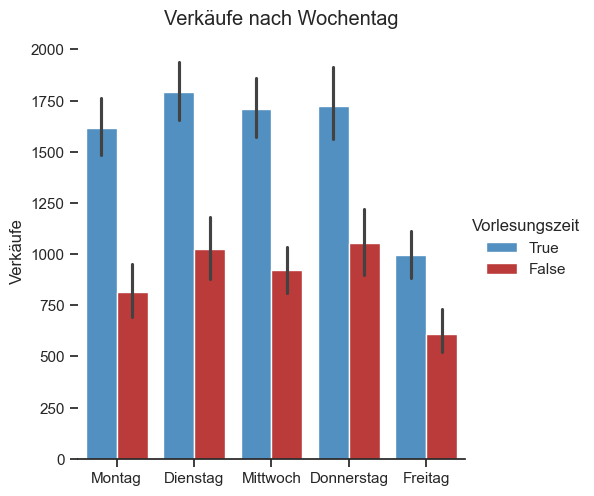

In [23]:
sns.set_theme('notebook', 'ticks')

g = sns.catplot(data=weekday_plot_df, x='weekday', y='sales', hue='Vorlesungszeit', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'], kind='bar', palette=weekday_color_palette)
g.set_axis_labels(x_var='', y_var='Verkäufe')
g.set_xticklabels(['Montag', 'Dienstag', 'Mittwoch', 'Donnerstag', 'Freitag'])
g.figure.suptitle('Verkäufe nach Wochentag', y=1.03)
g.despine(left=True)

g.savefig('../../plots/verkaeufe_nach_wochentag_bars.png')

### Correlations

In [32]:
corr_frame = (prepped_data
              .with_columns(
                  Vorlesungszeit=pl.when(pl.col('academic_bucket') == 'lecture')
                  .then(pl.lit(1))
                  .otherwise(pl.lit(0))
              )
              .select(['sales', 'sunshine_duration', 'precipitation_hours', 'precipitation_sum', 'apparent_temperature_mean', 'day_of_week', 'day_of_month', 'day_of_year', 'Vorlesungszeit'])
              .drop_nulls())

summary_stats = pl.DataFrame({
    'variable': corr_frame.columns,
    'n': [corr_frame.select(pl.col(c).drop_nulls().len()).item() for c in corr_frame.columns],
    'mean': [round(corr_frame[c].mean(), 2) for c in corr_frame.columns],
    'std': [round(corr_frame[c].std(), 2) for c in corr_frame.columns],
})

value_cols = [c for c in corr_frame.columns if c != 'date']
rows = []

for i, x in enumerate(value_cols):
    for y in value_cols[i + 1:]:
        pair = corr_frame.select([x, y]).drop_nulls()
        n = pair.height

        if n < 3:
            rows.append({
                'x': x,
                'y': y,
                'n': n,
                'r': None,
                'p_value': None,
            })
            continue

        r, p = pearsonr(pair[x].to_numpy(), pair[y].to_numpy())

        rows.append({
            'x': x,
            'y': y,
            'n': n,
            'r': round(r, 2),
            'p_value': p,
        })

corr_tests = pl.DataFrame(rows)

valid_p = corr_tests.filter(pl.col('p_value').is_not_null())

reject, p_adj, _, _ = multipletests(
    valid_p['p_value'].to_numpy(),
    alpha=0.05,
    method='fdr_bh',
)

valid_p = valid_p.with_columns([
    pl.Series('p_adj', p_adj),
    pl.Series('significant', reject),
])

valid_p

x,y,n,r,p_value,p_adj,significant
str,str,i64,f64,f64,f64,bool
"""sales""","""sunshine_duration""",242,-0.16,0.015805,0.047415,true
"""sales""","""precipitation_hours""",242,0.01,0.895404,0.979851,false
"""sales""","""precipitation_sum""",242,-0.01,0.820952,0.979851,false
"""sales""","""apparent_temperature_mean""",242,-0.36,1.1178e-8,6.7069e-8,true
"""sales""","""day_of_week""",242,-0.24,0.000204,0.000816,true
…,…,…,…,…,…,…
"""day_of_week""","""day_of_year""",242,0.01,0.865886,0.979851,false
"""day_of_week""","""Vorlesungszeit""",242,-0.0,0.99664,0.99664,false
"""day_of_month""","""day_of_year""",242,-0.02,0.764369,0.979851,false


### Sales Insights reagarding dishes

In [76]:
# the consistency score makes it possible to rank dishes that have high mean and low variance. this is only meaningful for dishes sold on at least two days hence dishes sold on one day are omitted.

dish_stats = (
    sales_processed
    .filter(pl.col('meal_category').is_in(['Menü 1', 'Menü 2', 'Eintopf Groß', 'Dessert', 'Joker', 'Salatteller', 'Sweet Joker', 'Tellergericht Pasta Cor.']))
    .group_by('meal_name', 'meal_category')
    .agg([
        pl.col('sales').sum().alias('total_sold'),
        pl.col('sales').mean().alias('avg_sold'),
        pl.col('sales').std().alias('std_sold'),
        pl.col('date').n_unique().alias('days_sold'),
    ])
    .with_columns(
        (
            pl.col('std_sold') / pl.col('avg_sold')
        ).alias('cv')
    )
    .with_columns([
        (
            pl.col('avg_sold')
            / (1 + (pl.col('cv')))
        ).alias('consistency_score'),
    ])
    .filter(
        # filter out items that have been sold on less than 12 days because they havent been sold often enough for reliable analysis
        (pl.col('days_sold') >= 5) &
        # filter the final frame at the 10 percentile to cut out dishes with low sales
        (pl.col('total_sold') >= pl.col('total_sold').quantile(0.1))
    )
)

dish_stats.write_csv('../../data/processed/dish_stats.csv')
dish_stats

meal_name,meal_category,total_sold,avg_sold,std_sold,days_sold,cv,consistency_score
str,str,i64,f64,f64,u32,f64,f64
"""Pasta-Linsenbolognese-vegan DG…","""Tellergericht Pasta Cor.""",1369,195.571429,76.759054,7,0.392486,140.447677
"""Fischroulade-Möhren-Salzkartof…","""Menü 2""",481,80.166667,19.062179,6,0.237782,64.766393
"""Schokoladenkuchen-vegan DGE*""","""Sweet Joker""",1589,176.555556,97.58344,9,0.552707,113.708245
"""hausgemachter Vanillepudding m…","""Sweet Joker""",724,90.5,38.626416,8,0.426811,63.428153
"""Mandelkuchen-vegan DGE*""","""Sweet Joker""",1197,99.75,71.724378,12,0.719041,58.026526
…,…,…,…,…,…,…,…
"""Pasta mit Fleischbällchen in T…","""Tellergericht Pasta Cor.""",1542,220.285714,85.548649,7,0.388353,158.666918
"""hausgemachter Milchreis mit Ki…","""Sweet Joker""",1405,140.5,80.402114,10,0.572257,89.361979
"""Backfisch auf Spinat-Risone-Ri…","""Menü 2""",1815,259.285714,85.960678,7,0.331529,194.727833


In [77]:
cutoffs = dish_stats.select([
    pl.col('avg_sold').quantile(0.75).alias('high_sales_cutoff'),
    pl.col('avg_sold').quantile(0.25).alias('low_sales_cutoff'),
    pl.col('cv').quantile(0.25).alias('stable_cutoff'),
    pl.col('cv').quantile(0.75).alias('unstable_cutoff'),
]).row(0, named=True)

high_sales_cutoff = cutoffs['high_sales_cutoff']
low_sales_cutoff = cutoffs['low_sales_cutoff']
stable_cutoff = cutoffs['stable_cutoff']
unstable_cutoff = cutoffs['unstable_cutoff']

dish_segments = (
    dish_stats
    .with_columns(
        pl.when(
            (pl.col('avg_sold') >= high_sales_cutoff) &
            (pl.col('cv') <= stable_cutoff)
        )
        .then(pl.lit('Konsistent starke Verkäufe'))

        .when(
            (pl.col('avg_sold') <= low_sales_cutoff) &
            (pl.col('cv') <= stable_cutoff)
        )
        .then(pl.lit('Konsistent schwache Verkäufe'))

        .when(
            (pl.col('avg_sold') >= high_sales_cutoff) &
            (pl.col('cv') >= unstable_cutoff)
        )
        .then(pl.lit('Starke Verkäufe aber volatil'))

        .when(
            (pl.col('avg_sold') <= low_sales_cutoff) &
            (pl.col('cv') >= unstable_cutoff)
        )
        .then(pl.lit('Niedrige Verkäufe und unvorhersehbar'))

        .otherwise(pl.lit('Mittlerer Bereich'))
        .alias('segment')
    )
)

In [29]:
strong_table = (
    dish_segments
    .filter(pl.col('segment') == 'Konsistent starke Verkäufe')
    .sort(['avg_sold', 'cv'], descending=[True, False])
    .select(['meal_name', 'meal_category', 'total_sold', 'avg_sold', 'cv', 'days_sold'])
    .head(20)
)

weak_table = (
    dish_segments
    .filter(pl.col('segment') == 'Konsistent schwache Verkäufe')
    .sort(['avg_sold', 'cv'], descending=[False, False])
    .select(['meal_name', 'meal_category', 'total_sold', 'avg_sold', 'cv', 'days_sold'])
    .head(20)
)

volatile_table = (
    dish_segments
    .sort(['cv', 'total_sold'], descending=[True, True])
    .select(['meal_name', 'meal_category', 'total_sold', 'avg_sold', 'std_sold', 'cv', 'days_sold'])
    .head(20)
)

In [78]:
segment_colors = {
    'Konsistent starke Verkäufe': '#53A12E',
    'Konsistent schwache Verkäufe': '#D02525',
    'Starke Verkäufe aber volatil': '#F3B700',
    'Niedrige Verkäufe und unvorhersehbar': '#3F92D2',
    'Mittlerer Bereich': '#9E9E9E',
}

plot_df = (
    dish_segments
    .rename({
        'meal_name': 'Gericht',
        'meal_category': 'Kategorie',
        'total_sold': 'Verkäufe Gesamt',
        'avg_sold': 'Durchschnittliche Verkäufe/Tag',
        'cv': 'Koeffizient der Varianz',
        'days_sold': 'An Tagen verkauft',
        'segment': 'Segment',
    })
    .to_pandas()
)

fig = px.scatter(
    plot_df,
    x='Durchschnittliche Verkäufe/Tag',
    y='Koeffizient der Varianz',
    color='Segment',
    size='Verkäufe Gesamt',
    hover_name='Gericht',
    hover_data={
        'Kategorie': True,
        'Verkäufe Gesamt': True,
        'Durchschnittliche Verkäufe/Tag': ':.2f',
        'Koeffizient der Varianz': ':.2f',
        'An Tagen verkauft': True,
        'Segment': False,
    },
    color_discrete_map=segment_colors,
    size_max=30,
    title='Verkaufsstabilität von Gerichten'
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Durchschnittliche Verkäufe/Tag',
    yaxis_title='Koeffizient der Varianz (CV)',
    legend_title='Segment',
    legend=dict(
        x=1,
        y=1,
        xanchor="right",
        yanchor="top",
        bordercolor="black",
        borderwidth=1,
    )
)

fig.update_yaxes(range=[0, 1])

fig.add_vline(
    x=low_sales_cutoff,
    line_dash='dash',
    line_color='gray',
    annotation_text='Wenige Verkäufe ',
    annotation_position='top left'
)

fig.add_vline(
    x=high_sales_cutoff,
    line_dash='dash',
    line_color='gray',
    annotation_text=' Viele Verkäufe',
    annotation_position='top right'
)

fig.add_hline(
    y=stable_cutoff,
    line_dash='dash',
    line_color='gray',
    annotation_text='Stabiler Bereich',
    annotation_position='bottom right'
)

fig.add_hline(
    y=unstable_cutoff,
    line_dash='dash',
    line_color='gray',
    annotation_text='Instabiler Bereich',
    annotation_position='top right'
)

fig.show()
fig.write_html('../../plots/sales_strength_stability.html')
fig.write_image('../../plots/verkaufsstabilitaet_gerichte.png', width=1200, height=650, scale=2)